# Naive Bayes Classification

В этом ноутбуке рассмотрим:
- как модель считает вероятности классов
- где работает хорошо, а где плохо
- сравнение с **Logistic Regression**
- метрики: Accuracy, Precision, Recall, F1, ROC-AUC, Log Loss

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, log_loss,
                             confusion_matrix, roc_curve)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)

## Как модель считает вероятности

Теорема Байеса:

$$P(y \mid x) = \frac{P(x \mid y) \cdot P(y)}{P(x)}$$

Нормальное распределение, **Gaussian NB**:

$$P(x_i \mid y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i-\mu_y)^2}{2\sigma_y^2}\right)$$

Признаки считаются **независимыми** (отсюда «naive»):

$$P(x \mid y) = \prod_i P(x_i \mid y)$$

## Датасет 1 — там, где Naive Bayes работает хорошо

Два хорошо разделимых гауссовых облака.

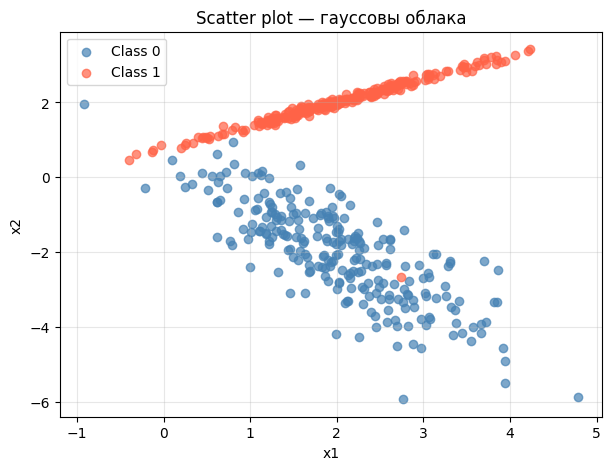

In [34]:
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1,
                           class_sep=2.0, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', label='Class 0', alpha=0.7)
plt.scatter(X[y==1, 0], X[y==1, 1], c='tomato',    label='Class 1', alpha=0.7)
plt.title('Scatter plot — гауссовы облака')
plt.xlabel('x1'); plt.ylabel('x2'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [35]:
gnb = GaussianNB().fit(X_train, y_train)

proba = gnb.predict_proba(X_test[:5])
pd.DataFrame(proba, columns=['P(class=0)', 'P(class=1)']).round(3)

,P(class=0),P(class=1)
0,0.026,0.974
1,0.019,0.981
2,1.000,0.000
3,0.003,0.997
4,1.000,0.000


Параметры, которые модель выучила (среднее и дисперсия по каждому классу):

In [36]:
print('Class priors P(y):', gnb.class_prior_.round(3))
print('Means по классам:\n', gnb.theta_.round(3))
print('Variances по классам:\n', gnb.var_.round(3))

Class priors P(y): [0.497 0.503]
Means по классам:
 [[ 1.996 -1.974]
 [ 2.057  2.006]]
Variances по классам:
 [[0.775 1.596]
 [0.651 0.384]]


## Decision boundary

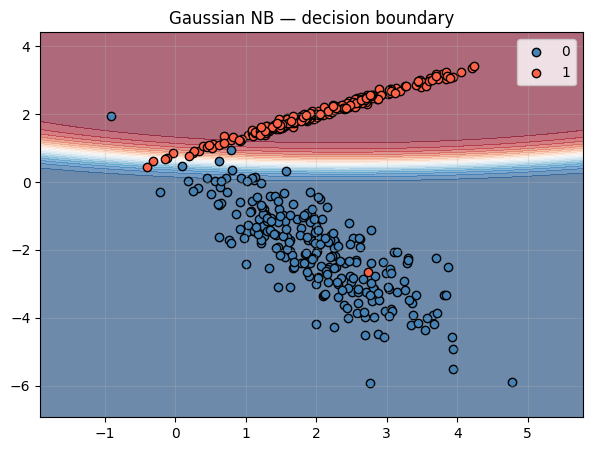

In [37]:
def plot_boundary(model, X, y, title):
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
                         np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300))
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
    plt.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.6)
    plt.scatter(X[y==0,0], X[y==0,1], c='steelblue', edgecolor='k', label='0')
    plt.scatter(X[y==1,0], X[y==1,1], c='tomato',    edgecolor='k', label='1')
    plt.title(title); plt.legend(); plt.grid(alpha=0.3)
    plt.show()

plot_boundary(gnb, X, y, 'Gaussian NB — decision boundary')

## Где Naive Bayes работает плохо

«Луны» — нелинейная граница, и признаки **не независимы**. Гауссова модель тут слабая.

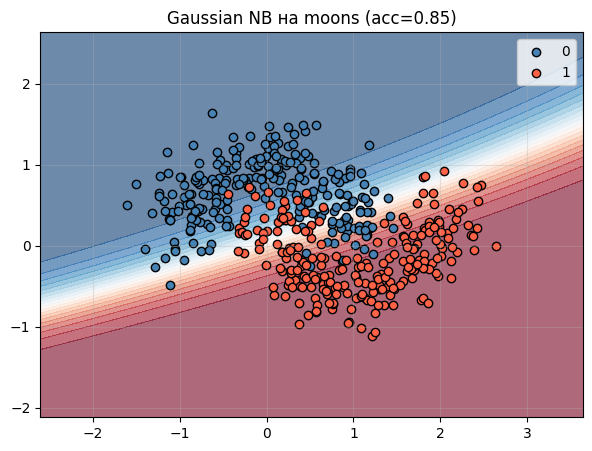

In [38]:
Xm, ym = make_moons(n_samples=500, noise=0.25, random_state=42)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.3, random_state=42)

gnb_m = GaussianNB().fit(Xm_tr, ym_tr)
plot_boundary(gnb_m, Xm, ym, f'Gaussian NB на moons (acc={gnb_m.score(Xm_te, ym_te):.2f})')

## Сравнение с Logistic Regression

Возвращаемся к «лёгкому» (первому) датасету и считаем все метрики.

In [39]:
logreg = LogisticRegression().fit(X_train, y_train)

def metrics(model, X_te, y_te):
    pred  = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    return {
        'Accuracy':  accuracy_score(y_te, pred),
        'Precision': precision_score(y_te, pred),
        'Recall':    recall_score(y_te, pred),
        'F1':        f1_score(y_te, pred),
        'ROC-AUC':   roc_auc_score(y_te, proba),
        'LogLoss':   log_loss(y_te, proba),
    }

results = pd.DataFrame({
    'GaussianNB': metrics(gnb,    X_test, y_test),
    'LogReg':     metrics(logreg, X_test, y_test),
}).round(3)
results

,GaussianNB,LogReg
Accuracy,0.973,0.973
Precision,0.986,1.000
Recall,0.960,0.947
F1,0.973,0.973
ROC-AUC,0.999,0.998
LogLoss,0.039,0.073


## Confusion matrix

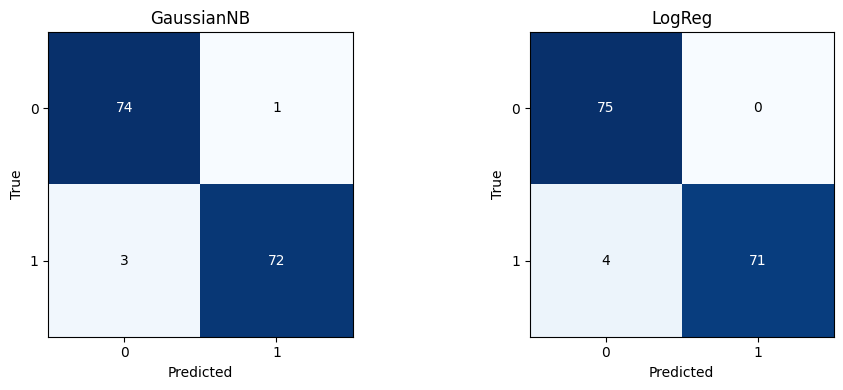

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, [('GaussianNB', gnb), ('LogReg', logreg)]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout(); plt.show()

## ROC curve

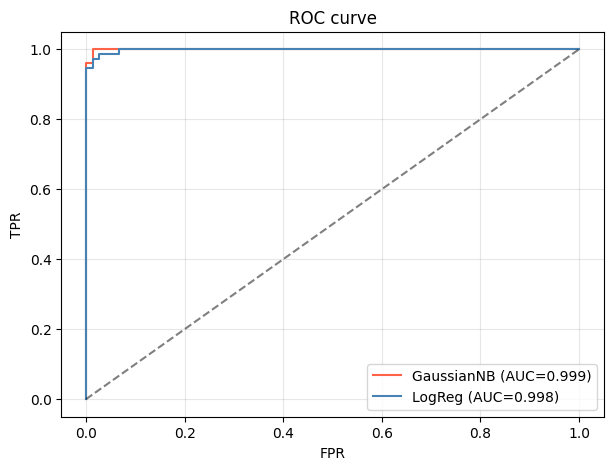

In [41]:
for name, model, color in [('GaussianNB', gnb, 'tomato'),
                            ('LogReg',     logreg, 'steelblue')]:
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC curve')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## Метрики — bar chart

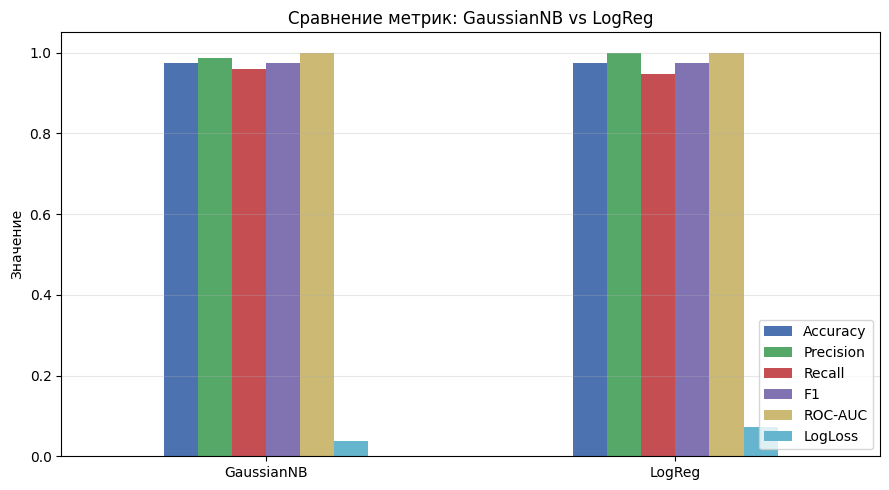

In [42]:
ax = results.T.plot(kind='bar', figsize=(9, 5),
                    color=['#4C72B0', '#55A868', '#C44E52',
                           '#8172B2', '#CCB974', '#64B5CD'])
plt.title('Сравнение метрик: GaussianNB vs LogReg')
plt.ylabel('Значение'); plt.xticks(rotation=0)
plt.legend(loc='lower right'); plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

#**Общий итог:**

- **Gaussian NB** хорошо работает, когда признаки распределены ~ нормально и слабо зависимы.
- На сложных нелинейных границах (например «луны») он проигрывает.
- **Logistic Regression** обычно даёт чуть лучшее качество и более калиброванные вероятности.
- Naive Bayes выигрывает в **скорости** и хорошо работает при **малом количестве данных** и в задачах с большим числом признаков (например, тексты).